In [1]:
import os
import glob
import json
import numpy as np
import random
import wandb
import time
import cv2
import math
from tqdm import tqdm
import argparse # 인자 파싱을 위해 추가
import threading

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms
from PIL import Image
from transformers import AutoModel, SiglipVisionModel
from scipy.spatial.transform import Rotation as R

# DDP 관련 라이브러리
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler

seed = 100
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

/home/najo/.conda/envs/dinov3/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/najo/.conda/envs/dinov3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ======================= DDP 설정 함수 =======================
def setup_ddp():
    """DDP 프로세스 그룹을 초기화합니다."""
    dist.init_process_group(backend="nccl")
    rank = int(os.environ["RANK"])
    local_rank = int(os.environ["LOCAL_RANK"])
    world_size = int(os.environ["WORLD_SIZE"])
    torch.cuda.set_device(local_rank)
    return rank, local_rank, world_size

def cleanup_ddp():
    """DDP 프로세스 그룹을 정리합니다."""
    dist.destroy_process_group()

# ======================= 데이터셋 클래스 및 함수 =======================
def create_gt_heatmap(keypoint_2d, heatmap_size, sigma):
    H, W = heatmap_size
    x, y = keypoint_2d
    xx, yy = np.meshgrid(np.arange(W), np.arange(H))
    dist_sq = (xx - x)**2 + (yy - y)**2
    heatmap = np.exp(-dist_sq / (2 * sigma**2))
    heatmap[heatmap < np.finfo(float).eps * heatmap.max()] = 0
    return heatmap

def _scale_points(points_xy, from_size, to_size):
    Wf, Hf = from_size
    Wt, Ht = to_size
    out = np.empty_like(points_xy, dtype=np.float32)
    out[:, 0] = points_xy[:, 0] * (Wt / float(Wf))
    out[:, 1] = points_xy[:, 1] * (Ht / float(Hf))
    return out

In [13]:
# ===== Dataset __getitem__ 반환 통일 =====
class RobotPoseDataset(Dataset):
    def __init__(self, json_files, transform, sigma=2.0):
        self.json_files = json_files
        self.transform = transform
        self.sigma = sigma

    def __len__(self):
        return len(self.json_files)

    def __getitem__(self, idx):
        json_path = self.json_files[idx]
        with open(json_path, "r", encoding="utf-8") as f:
            sample = json.load(f)
        
        image_path = sample['meta']['image_path']
        img_bgr = cv2.imread(image_path)
        if img_bgr is None:
            # 다음 샘플로 대체
            return self.__getitem__((idx + 1) % len(self))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]
        img_pil = Image.fromarray(img_rgb)
        image_tensor = self.transform(img_pil)

        # 2D heatmap GT
        Ht, Wt = (224, 224)
        keypoints = sample["objects"][0]["keypoints"]
        joint_num = len(keypoints)
        kpts_2d_orig = np.array([kp["projected_location"] for kp in keypoints], dtype=np.float32)
        kpts_on_heatmap = _scale_points(kpts_2d_orig, from_size=(w, h), to_size=(Wt, Ht))
        heatmaps_np = np.zeros((joint_num, Ht, Wt), dtype=np.float32)
        for i in range(joint_num):
            heatmaps_np[i] = create_gt_heatmap(kpts_on_heatmap[i], (Ht, Wt), self.sigma)
        gt_heatmaps = torch.from_numpy(heatmaps_np)  # (J, H, W)

        angles = [angle["position"] for angle in sample['sim_state']["joints"]]
        gt_angles = torch.tensor(angles, dtype=torch.float32)  # (A,)
        gt_class = sample['objects'][0]['class']
        gt_3d_points = torch.tensor([kp["location"] for kp in keypoints])  # (J,3)
        K = torch.tensor(sample['meta']['K'], dtype=torch.float32)  # (3,3)

        if 'dist_coeffs' in sample['meta'] and len(sample['meta']['dist_coeffs']) > 0:
            dist = torch.tensor(sample['meta']['dist_coeffs'], dtype=torch.float32)
        else:
            dist = torch.zeros(5, dtype=torch.float32)  # 보통 k1,k2,p1,p2,k3 → 5개 기본

        kpts_2d_orig = torch.from_numpy(kpts_2d_orig)
        return image_tensor, gt_heatmaps, gt_angles, gt_class, gt_3d_points, K, dist, kpts_2d_orig

def robot_collate_fn(batch):
    image_tensor, gt_heatmaps, gt_angles, gt_class, gt_3d_points, K, dist, kpts_2d_orig = zip(*batch)
    image_tensors = torch.stack(image_tensor, 0)
    
    MAX_JOINTS = 7
    MAX_ANGLES = 9
    MAX_POINTS = 7

    heatmaps_padded = torch.zeros(len(gt_heatmaps), MAX_JOINTS, gt_heatmaps[0].shape[1], gt_heatmaps[0].shape[2])
    angles_padded   = torch.zeros(len(gt_angles), MAX_ANGLES)
    points_padded   = torch.zeros(len(gt_3d_points), MAX_POINTS, 3)
    points_2d_padded= torch.zeros(len(kpts_2d_orig), MAX_JOINTS, 2)

    for i, (h, a, p, p2) in enumerate(zip(gt_heatmaps, gt_angles, gt_3d_points, kpts_2d_orig)):
        joint_num = h.shape[0]
        angle_num = a.shape[0]
        point_num = p.shape[0]

        heatmaps_padded[i, :joint_num, :, :] = h
        angles_padded[i, :angle_num] = a
        points_padded[i, :point_num] = p
        points_2d_padded[i, :joint_num, :] = p2

    K = torch.stack(K, 0)

    return image_tensors, heatmaps_padded, angles_padded, gt_class, points_padded, K, dist, points_2d_padded

transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

json_files = glob.glob("../dataset/Converted_dataset/**/*.json", recursive=True)

LEARNING_RATE = 1e-5
BATCH_SIZE = 1000
EPOCHS = 100
VAL_RATIO = 0.1

full_dataset = RobotPoseDataset(json_files, transform)
train_size = int(len(full_dataset) * (1 - VAL_RATIO))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=robot_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=robot_collate_fn)

image_tensors, heatmaps_padded, angles_padded, gt_class, gt_3d_points_padded, K, dist, points_2d_padded = next(iter(train_loader))

In [14]:
FEATURE_DIM = 512
NUM_ANGLES = 9
NUM_JOINTS = 7

class DINOv3Backbone(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.model_name = model_name
        if "siglip" in model_name:
            self.model = SiglipVisionModel.from_pretrained(model_name)
        else:
            self.model = AutoModel.from_pretrained(model_name)
    def forward(self, image_tensor_batch):
        with torch.no_grad():
            if "siglip" in self.model_name:
                outputs = self.model(
                    pixel_values=image_tensor_batch,
                    interpolate_pos_encoding=True)
                tokens = outputs.last_hidden_state
                patch_tokens = tokens[:, 1:, :]
            else: # DINOv3 계열
                outputs = self.model(pixel_values=image_tensor_batch)
                tokens = outputs.last_hidden_state
                num_reg = int(getattr(self.model.config, "num_register_tokens", 0))
                patch_tokens = tokens[:, 1 + num_reg :, :]
            return patch_tokens

class JointAngleHead(nn.Module):
    def __init__(self, input_dim=FEATURE_DIM, num_angles=NUM_ANGLES, num_queries=4, nhead=8, num_decoder_layers=2):
        super().__init__()
        
        self.pose_queries = nn.Parameter(torch.randn(1, num_queries, input_dim))
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=input_dim, 
            nhead=nhead, 
            dim_feedforward=input_dim * 4, # 일반적인 설정
            dropout=0.1, 
            activation='gelu',
            batch_first=True  # (batch, seq, feature) 입력을 위함
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_decoder_layers)
        self.angle_predictor = nn.Sequential(
            nn.LayerNorm(input_dim * num_queries),
            nn.Linear(input_dim * num_queries, 512),
            nn.GELU(),
            nn.LayerNorm(512),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.LayerNorm(256),
            nn.Linear(256, num_angles)
        )
    
    def forward(self, fused_features):
        b = fused_features.size(0)
        queries = self.pose_queries.repeat(b, 1, 1)
        attn_output = self.transformer_decoder(tgt=queries, memory=fused_features)
        output_flat = attn_output.flatten(start_dim=1)
        return self.angle_predictor(output_flat)

class TokenFuser(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.refine_blocks = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        self.residual_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    def forward(self, x):
        projected = self.projection(x)
        refined = self.refine_blocks(projected)
        residual = self.residual_conv(x)
        return torch.nn.functional.gelu(refined + residual)

class LightCNNStem(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1, bias=False), # 해상도 1/2
            nn.BatchNorm2d(16),
            nn.GELU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1, bias=False), # 해상도 1/4
            nn.BatchNorm2d(32),
            nn.GELU()
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False), # 해상도 1/8
            nn.BatchNorm2d(64),
            nn.GELU()
        )
        
    def forward(self, x):
        feat_4 = self.conv_block1(x)  # 1/4 스케일 특징
        feat_8 = self.conv_block2(feat_4) # 1/8 스케일 특징
        return feat_4, feat_8 # 다른 해상도의 특징들을 반환

class FusedUpsampleBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.refine_conv = nn.Sequential(
            nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )

    def forward(self, x, skip_feature):
        x = self.upsample(x)
        if x.shape[-2:] != skip_feature.shape[-2:]:
            skip_feature = F.interpolate(
                skip_feature, 
                size=x.shape[-2:], # target H, W
                mode='bilinear', 
                align_corners=False
            )

        fused = torch.cat([x, skip_feature], dim=1)
        return self.refine_conv(fused)

class UNetViTKeypointHead(nn.Module):
    def __init__(self, input_dim=768, num_joints=NUM_JOINTS, heatmap_size=(224, 224)):
        super().__init__()
        self.heatmap_size = heatmap_size
        self.token_fuser = TokenFuser(input_dim, 256)
        self.decoder_block1 = FusedUpsampleBlock(in_channels=256, skip_channels=64, out_channels=128)
        self.decoder_block2 = FusedUpsampleBlock(in_channels=128, skip_channels=32, out_channels=64)
        self.final_upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.heatmap_predictor = nn.Conv2d(64, num_joints, kernel_size=3, padding=1)

    def forward(self, dino_features, cnn_features):
        cnn_feat_4, cnn_feat_8 = cnn_features
        b, n, d = dino_features.shape
        h = w = int(math.sqrt(n))

        if h * w != n:
            n_new = h * w
            dino_features = dino_features[:, :n_new, :]
        x = dino_features.permute(0, 2, 1).reshape(b, d, h, w)
        
        x = self.token_fuser(x)
        x = self.decoder_block1(x, cnn_feat_8)
        x = self.decoder_block2(x, cnn_feat_4)
        x = self.final_upsample(x)
        heatmaps = self.heatmap_predictor(x)
        
        return F.interpolate(heatmaps, size=self.heatmap_size, mode='bilinear', align_corners=False)
        
class DINOv3PoseEstimator(nn.Module):
    def __init__(self, dino_model_name, ablation_mode=None):
        super().__init__()
        # self.ablation_mode = ablation_mode
        self.dino_model_name = dino_model_name
        self.backbone = DINOv3Backbone(dino_model_name)
        
        if "siglip" in self.dino_model_name:
            config = self.backbone.model.config
            feature_dim = config.hidden_size
        else: # DINOv3 계열
            config = self.backbone.model.config
            feature_dim = config.hidden_sizes[-1] if "conv" in self.dino_model_name else config.hidden_size
        
        self.cnn_stem = LightCNNStem()
        self.keypoint_head = UNetViTKeypointHead(input_dim=feature_dim)
        self.angle_head = JointAngleHead(input_dim=feature_dim)      # 기존 Attention 헤드
        
    def forward(self, image_tensor_batch):
        dino_features = self.backbone(image_tensor_batch) # 항상 3D 텐서
        cnn_stem_features = self.cnn_stem(image_tensor_batch)
        predicted_heatmaps = self.keypoint_head(dino_features, cnn_stem_features)
        predicted_angles = self.angle_head(dino_features)
        
        return predicted_heatmaps, predicted_angles

In [15]:
def get_dh_matrix(a, d, alpha, theta):
    a_r, t_r = map(math.radians, (alpha, theta))
    ca, sa, ct, st = np.cos(a_r), np.sin(a_r), np.cos(t_r), np.sin(t_r)
    return np.array([
        [ ct, -st*ca,  st*sa, a*ct],
        [ st,  ct*ca, -ct*sa, a*st],
        [  0,     sa,     ca,    d],
        [  0,      0,      0,    1]
    ])

def get_modified_dh_matrix(a, d, alpha, theta):
    a_r, t_r = map(math.radians, (alpha, theta))
    ca, sa, ct, st = np.cos(a_r), np.sin(a_r), np.cos(t_r), np.sin(t_r)
    return np.array([
        [ ct, -st,  0, a],
        [ st*ca, ct*ca, -sa, -d*sa],
        [ st*sa, ct*sa,  ca,  d*ca],
        [ 0, 0, 0, 1]
    ])

# ======================= 베이스 클래스 =======================
class RobotKinematics:
    def __init__(self, name):
        self.name = name
    
    def forward_kinematics(self, joint_angles, view=None):
        raise NotImplementedError

    def _truncate_angles(self, joint_angles):
        return joint_angles[:len(self.dh_params)]

# ======================= Meca500 =======================
class MecaInsertionKinematics(RobotKinematics):
    def __init__(self):
        super().__init__("MecaInsertion")
        self.dh_params = [
            {'alpha': -90, 'a': 0,     'd': 0.135, 'theta_offset': 0},
            {'alpha': 0,   'a': 0.135, 'd': 0,     'theta_offset': -90},
            {'alpha': -90, 'a': 0.038, 'd': 0,     'theta_offset': 0},
            {'alpha': 90,  'a': 0,     'd': 0.120, 'theta_offset': 0},
            {'alpha': -90, 'a': 0,     'd': 0,     'theta_offset': 0},
            {'alpha': 0,   'a': 0,     'd': 0.070, 'theta_offset': 0}
        ]
        # 베이스 보정
        rot_x_180 = R.from_euler('x', 180, degrees=True)
        rot_z_90 = R.from_euler('z', 90, degrees=True)
        self.base_correction = (rot_z_90 * rot_x_180).as_matrix()

    def forward_kinematics(self, joint_angles, view=None):
        joint_coords = [np.array([0,0,0])]
        T_cumulative = np.eye(4)
        T_cumulative[:3,:3] = self.base_correction
        base_point = np.array([[0],[0],[0],[1]])
        for i, params in enumerate(self.dh_params):
            theta = math.degrees(joint_angles[i]) + params['theta_offset']
            T_i = get_dh_matrix(params['a'], params['d'], params['alpha'], theta)
            T_cumulative = T_cumulative @ T_i
            joint_coords.append((T_cumulative @ base_point)[:3,0])
        return np.array(joint_coords, dtype=np.float32)

class Meca500Kinematics(RobotKinematics):
    def __init__(self):
        super().__init__("Meca500")
        self.dh_params = [
            {'alpha': -90, 'a': 0,     'd': 0.135, 'theta_offset': 0},
            {'alpha': 0,   'a': 0.135, 'd': 0,     'theta_offset': -90},
            {'alpha': -90, 'a': 0.038, 'd': 0,     'theta_offset': 0},
            {'alpha': 90,  'a': 0,     'd': 0.120, 'theta_offset': 0},
            {'alpha': -90, 'a': 0,     'd': 0,     'theta_offset': 0},
            {'alpha': 0,   'a': 0,     'd': 0.070, 'theta_offset': 0}
        ]
    def forward_kinematics(self, joint_angles, view=None):
        joint_coords_3d = [np.array([0, 0, 0])] # J0 (베이스)
        T_cumulative = np.eye(4)
        base_point = np.array([[0], [0], [0], [1]])
        for i in range(6):
            params = self.dh_params[i]
            theta = math.degrees(joint_angles[i]) + params['theta_offset']
            T_i = get_dh_matrix(params['a'], params['d'], params['alpha'], theta)
            T_cumulative = T_cumulative @ T_i
            joint_pos = T_cumulative @ base_point
            joint_coords_3d.append(joint_pos[:3, 0])
        return np.array(joint_coords_3d, dtype=np.float32)

# ======================= Franka Research 3 =======================
class Research3Kinematics(RobotKinematics):
    def __init__(self):
        super().__init__("research3")
        self.dh_params = [
            {'a': 0,      'd': 0.333, 'alpha':   0, 'theta_offset': 0}, 
            {'a': 0,      'd': 0,     'alpha': -90, 'theta_offset': 0},
            {'a': 0,      'd': 0.316, 'alpha':  90, 'theta_offset': 0},
            {'a': 0.0825, 'd': 0,     'alpha':  90, 'theta_offset': 0},
            {'a':-0.0825, 'd': 0.384, 'alpha': -90, 'theta_offset': 0},
            {'a': 0,      'd': 0,     'alpha':  90, 'theta_offset': 0},
            {'a': 0.088,  'd': 0,     'alpha':  90, 'theta_offset': 0}, 
            {'a': 0,      'd': 0.107, 'alpha':   0, 'theta_offset': 0}
        ]
        self.view_rotations = {
            'view1': R.from_euler('zyx',[90,180,0],degrees=True),
            'view2': R.from_euler('zyx',[90,180,0],degrees=True),
            'view3': R.from_euler('zyx',[90,180,0],degrees=True),
            'view4': R.from_euler('zyx',[90,180,0],degrees=True)
        }
        # 제외할 인덱스 (0부터 시작, base point 포함)
        self.exclude_indices = {1, 5}  

    def forward_kinematics(self, joint_angles, view="view1"):
        joint_coords = [np.array([0,0,0])]
        T_cumulative = np.eye(4)
        if view in self.view_rotations:
            T_cumulative[:3,:3] = self.view_rotations[view].as_matrix()
        base_point = np.array([[0],[0],[0],[1]])
        for i, angle_rad in enumerate(joint_angles):
            params = self.dh_params[i]
            theta_deg = math.degrees(angle_rad) + params['theta_offset']
            T_i = get_modified_dh_matrix(params['a'], params['d'], params['alpha'], theta_deg)
            T_cumulative = T_cumulative @ T_i
            joint_coords.append((T_cumulative @ base_point)[:3,0])
        # 제외할 인덱스 제거 후 반환
        filtered_coords = [pt for j, pt in enumerate(joint_coords) if j not in self.exclude_indices]
        return np.array(filtered_coords, dtype=np.float32)


# ======================= Panda franka =======================
class PandaKinematics(RobotKinematics):
    def __init__(self):
        super().__init__("panda")
        self.dh_params = [
            {'a': 0,      'd': 0.333, 'alpha':   0, 'theta_offset': 0}, 
            {'a': 0,      'd': 0,     'alpha': -90, 'theta_offset': 0},
            {'a': 0,      'd': 0.316, 'alpha':  90, 'theta_offset': 0},
            {'a': 0.0825, 'd': 0,     'alpha':  90, 'theta_offset': 0},
            {'a':-0.0825, 'd': 0.384, 'alpha': -90, 'theta_offset': 0},
            {'a': 0,      'd': 0,     'alpha':  90, 'theta_offset': 0},
            {'a': 0.088,  'd': 0,     'alpha':  90, 'theta_offset': 0}, 
            {'a': 0,      'd': 0.107, 'alpha':   0, 'theta_offset': 0}
        ]
        self.view_rotations = {
            'view1': R.from_euler('zyx',[90,180,0],degrees=True),
            'view2': R.from_euler('zyx',[90,180,0],degrees=True),
            'view3': R.from_euler('zyx',[90,180,0],degrees=True),
            'view4': R.from_euler('zyx',[90,180,0],degrees=True)
        }
        self.exclude_indices = {1, 5}

    def forward_kinematics(self, joint_angles, view="view1"):
        joint_coords = [np.array([0,0,0])]
        T_cumulative = np.eye(4)
        if view in self.view_rotations:
            T_cumulative[:3,:3] = self.view_rotations[view].as_matrix()
        base_point = np.array([[0],[0],[0],[1]])
        for i, angle_rad in enumerate(joint_angles):
            params = self.dh_params[i]
            theta_deg = math.degrees(angle_rad) + params['theta_offset']
            T_i = get_modified_dh_matrix(params['a'], params['d'], params['alpha'], theta_deg)
            T_cumulative = T_cumulative @ T_i
            joint_coords.append((T_cumulative @ base_point)[:3,0])
        filtered_coords = [pt for j, pt in enumerate(joint_coords) if j not in self.exclude_indices]
        return np.array(filtered_coords, dtype=np.float32)


# ======================= FR5 =======================
class Fr5Kinematics(RobotKinematics):
    def __init__(self):
        super().__init__("Fr5")
        self.dh_params = [
            {'alpha': 90,  'a': 0,      'd': 0.152, 'theta_offset': 0},
            {'alpha': 0,   'a': -0.425, 'd': 0,     'theta_offset': 0},
            {'alpha': 0,   'a': -0.395, 'd': 0,     'theta_offset': 0},
            {'alpha': 90,  'a': 0,      'd': 0.102, 'theta_offset': 0},
            {'alpha':-90,  'a': 0,      'd': 0.102, 'theta_offset': 0},
            {'alpha': 0,   'a': 0,      'd': 0.100, 'theta_offset': 0}
        ]
        self.view_rotations = {
            'top':   R.from_euler('zyx',[-85,0,180],degrees=True),
            'left':  R.from_euler('zyx',[180,0,90], degrees=True),
            'right': R.from_euler('zyx',[0,0,90],   degrees=True)
        }

    def forward_kinematics(self, joint_angles, view="top"):
        joint_coords = [np.array([0,0,0])]
        T_cumulative = np.eye(4)
        if view in self.view_rotations:
            T_cumulative[:3,:3] = self.view_rotations[view].as_matrix()
        base_point = np.array([[0],[0],[0],[1]])
        for i, params in enumerate(self.dh_params):
            theta = math.degrees(joint_angles[i]) + params['theta_offset']
            T_i = get_dh_matrix(params['a'], params['d'], params['alpha'], theta)
            T_cumulative = T_cumulative @ T_i
            joint_coords.append((T_cumulative @ base_point)[:3,0])
        return np.array(joint_coords, dtype=np.float32)

# ======================= 팩토리 함수 =======================
ROBOT_CLASSES = {
    "Meca500": Meca500Kinematics,
    "MecaInsertion": MecaInsertionKinematics,
    "research3": Research3Kinematics,
    "Fr5":     Fr5Kinematics,
    "panda":   PandaKinematics}

def get_robot_kinematics(robot_name):
    if robot_name not in ROBOT_CLASSES:
        raise ValueError(f"Unknown robot: {robot_name}")
    return ROBOT_CLASSES[robot_name]()

In [16]:
import numpy as np
import cv2
import torch

def _to_np(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def select_valid_correspondences(joints_3d_robot, kpts2d_padded):
    joints_3d_robot = _to_np(joints_3d_robot).astype(np.float64)
    kpts2d_padded   = _to_np(kpts2d_padded).astype(np.float64)
    valid2d_mask = np.linalg.norm(kpts2d_padded, axis=1) > 0.0
    idx2d = np.where(valid2d_mask)[0]

    if idx2d.size == 0:
        raise ValueError("No valid 2D keypoints found.")

    # 로봇 FK로 나온 관절 개수와 2D 유효 개수의 최소치만 사용
    n = int(min(len(joints_3d_robot), idx2d.size))
    objp = joints_3d_robot[:n]          # (n,3)
    imgp = kpts2d_padded[idx2d[:n]]     # (n,2)

    if n < 4:
        raise ValueError(f"Need at least 4 correspondences for PnP, got {n}.")
    return objp, imgp

def solve_pnp_from_fk(joints_3d_robot, kpts2d_padded, K, dist):
    objp, imgp = select_valid_correspondences(joints_3d_robot, kpts2d_padded)
    K   = _to_np(K).astype(np.float64)
    dist= _to_np(dist).astype(np.float64).reshape(-1,)
    ok, rvec, tvec = cv2.solvePnP(objp, imgp, K, dist, flags=cv2.SOLVEPNP_EPNP)
    rvec = rvec.reshape(3)
    tvec = tvec.reshape(3)
    return rvec, tvec, bool(ok)

def transform_robot_to_camera(joints_3d_robot, rvec, tvec):
    joints_3d_robot = _to_np(joints_3d_robot).astype(np.float64)
    R,_ = cv2.Rodrigues(rvec.reshape(3,1))
    t = tvec.reshape(3,1)
    X = joints_3d_robot.T  # (3,J)
    Y = (R @ X + t).T      # (J,3)
    return Y.astype(np.float32)

def reprojection_error(objp_cam, K, dist, rvec, tvec, imgp):
    K   = _to_np(K).astype(np.float64)
    dist= _to_np(dist).astype(np.float64).reshape(-1,)
    objp_cam = _to_np(objp_cam).astype(np.float64)
    imgp = _to_np(imgp).astype(np.float64)

    proj,_ = cv2.projectPoints(objp_cam, rvec, tvec, K, dist)
    proj = proj.reshape(-1,2)
    return float(np.linalg.norm(proj - imgp, axis=1).mean())

In [17]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
import torch

# 정규화 해제 함수
def unnormalize(img_tensor, mean, std):
    mean = torch.tensor(mean).view(3,1,1).to(img_tensor.device)
    std  = torch.tensor(std).view(3,1,1).to(img_tensor.device)
    return img_tensor * std + mean

def visualize_on_resized(idx, image_tensors, points_2d_padded, orig_hw, rvec=None, tvec=None, K=None, dist=None, objp=None):
    """
    idx: 샘플 인덱스
    image_tensors: (B,3,512,512) 학습용 이미지 텐서
    points_2d_padded: (B,MAX_JOINTS,2) 원본 좌표
    orig_hw: (H_orig, W_orig) 원본 이미지 크기
    """
    H_orig, W_orig = orig_hw

    # --- 정규화 해제 ---
    img = unnormalize(image_tensors[idx].cpu(),
                      mean=[0.485, 0.456, 0.406],
                      std=[0.229, 0.224, 0.225])
    img = torch.clamp(img, 0, 1)  # 값 클램핑
    img = TF.to_pil_image(img)

    plt.figure(figsize=(6,6))
    plt.imshow(img)

    # 1) GT 2D 좌표 (원본→512 스케일 변환)
    gt_2d = points_2d_padded[idx].cpu().numpy()
    scale_x, scale_y = 512 / W_orig, 512 / H_orig
    for (x,y) in gt_2d:
        if x <= 1 and y <= 1:  # 패딩 제외
            continue
        u, v = int(x * scale_x), int(y * scale_y)
        plt.scatter(u, v, c="lime", marker="o", s=40, 
                    label="GT 2D" if 'GT 2D' not in plt.gca().get_legend_handles_labels()[1] else "")

    # 2) FK→Cam reprojection (있을 경우)
    if rvec is not None and tvec is not None and objp is not None:
        proj,_ = cv2.projectPoints(objp, rvec, tvec, K.cpu().numpy(), dist.cpu().numpy())
        proj = proj.reshape(-1,2)
        for (x,y) in proj:
            u, v = int(x * scale_x), int(y * scale_y)
            plt.scatter(u, v, c="red", marker="x", s=40, 
                        label="FK→Cam Projected" if 'FK→Cam Projected' not in plt.gca().get_legend_handles_labels()[1] else "")

    plt.title(f"Sample {idx} (Resized 512x512)")
    plt.legend()
    plt.axis("off")
    plt.show()

tensor([[ 970.8260,  545.5172],
        [ 973.7722,  428.9792],
        [1061.9222,  409.0442],
        [1088.7568,  387.3025],
        [1162.3368,  544.4492],
        [1162.3368,  544.4492],
        [1145.3746,  618.1581]])
PnP OK: True rvec: [ 0.8732554 -0.1480883  0.3614545] tvec: [ 3.02545845e-08 -9.99998847e-03  4.01650103e-01]
Robot coords shape: [[0.         0.         0.        ]
 [0.         0.         0.135     ]
 [0.09384157 0.06451186 0.20750503]
 [0.11448058 0.07870024 0.23608337]
 [0.18884975 0.1298257  0.1569922 ]
 [0.18884975 0.1298257  0.1569922 ]
 [0.18884975 0.12982571 0.0869922 ]]
Cam coords shape: [[ 3.0254583e-08 -9.9999886e-03  4.0165010e-01]
 [ 2.6506262e-03 -1.1405918e-01  4.8761323e-01]
 [ 6.7502737e-02 -1.0875667e-01  6.0589719e-01]
 [ 8.2013980e-02 -1.1732730e-01  6.3995546e-01]
 [ 1.3072804e-01 -7.8702243e-03  6.4674425e-01]
 [ 1.3072804e-01 -7.8702243e-03  6.4674425e-01]
 [ 1.2935366e-01  4.6086397e-02  6.0217077e-01]]
GT 3D coords shape: tensor([[ 0.0000,

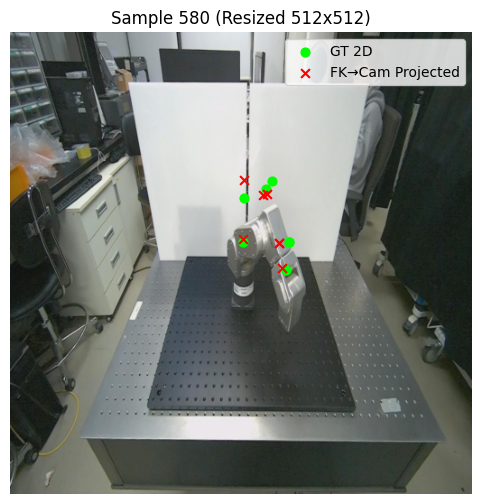

In [22]:
s = 580  # 샘플 인덱스
robot = get_robot_kinematics(gt_class[s])
joint_angles = robot._truncate_angles(angles_padded[s])   # (로봇 고유 관절 수)
joint_coords_robot = robot.forward_kinematics(joint_angles)  # (Jr,3), 로봇 좌표계

img_kpts2d = points_2d_padded[s]          # (MAX_JOINTS,2), 패딩 포함
K_s        = K[s]                 # (3,3)
dist_s     = dist[s]              # (8,) 또는 패딩 포함 8

print(img_kpts2d)

rvec, tvec, ok = solve_pnp_from_fk(joint_coords_robot, img_kpts2d, K_s, dist_s)
print("PnP OK:", ok, "rvec:", rvec, "tvec:", tvec)

joint_coords_cam = transform_robot_to_camera(joint_coords_robot, rvec, tvec)

print("Robot coords shape:", joint_coords_robot)
print("Cam coords shape:", joint_coords_cam)
print("GT 3D coords shape:", gt_3d_points_padded[s])

print("Robot:", robot.name, "| Cam coords shape:", joint_coords_cam.shape)
print("Robot:", robot.name, "| Cam coords shape:", gt_3d_points_padded[s].shape)

objp, imgp = select_valid_correspondences(joint_coords_robot, img_kpts2d)
err = reprojection_error(objp, K_s, dist_s, rvec, tvec, imgp)
print(f"Reprojection error (px): {err:.3f}")

H_orig, W_orig = 1200, 1920  # json에서 꺼내온 원본 해상도 넣어야 함
objp, imgp = select_valid_correspondences(joint_coords_robot, points_2d_padded[s])

visualize_on_resized(
    s,
    image_tensors,
    points_2d_padded,
    (H_orig, W_orig),
    rvec=rvec,
    tvec=tvec,
    K=K[s],
    dist=dist[s],
    objp=objp
)


In [20]:
target_classes = ["Meca500", "MecaInsertion", "research3", "Fr5", "panda"]

errors = []
for s in range(len(gt_class)):
    if gt_class[s] not in target_classes:
        continue

    robot = get_robot_kinematics(gt_class[s])
    joint_angles = robot._truncate_angles(angles_padded[s])
    joint_coords_robot = robot.forward_kinematics(joint_angles)

    img_kpts2d = points_2d_padded[s]
    K_s, dist_s = K[s], dist[s]

    rvec, tvec, ok = solve_pnp_from_fk(joint_coords_robot, img_kpts2d, K_s, dist_s)
    if not ok:
        continue

    objp, imgp = select_valid_correspondences(joint_coords_robot, img_kpts2d)
    err = reprojection_error(objp, K_s, dist_s, rvec, tvec, imgp)
    errors.append((s, gt_class[s], err))

    print(f"[{s}] Robot: {robot.name}, Error: {err:.2f}px")

# 전체 통계
if errors:
    errs_only = [e[2] for e in errors]
    print("===================================")
    print(f"총 {len(errors)}개 샘플")
    print(f"평균 reprojection error: {np.mean(errs_only):.2f}px")
    print(f"최대 error: {np.max(errs_only):.2f}px")
    print(f"최소 error: {np.min(errs_only):.2f}px")


[0] Robot: MecaInsertion, Error: 0.00px
[1] Robot: research3, Error: 0.00px
[2] Robot: panda, Error: 0.00px
[3] Robot: panda, Error: 0.00px
[4] Robot: panda, Error: 0.00px
[5] Robot: Fr5, Error: 0.00px
[6] Robot: research3, Error: 0.00px
[7] Robot: panda, Error: 0.00px
[8] Robot: panda, Error: 0.00px
[9] Robot: Fr5, Error: 0.00px
[10] Robot: panda, Error: 0.00px
[11] Robot: research3, Error: 0.00px
[12] Robot: panda, Error: 0.00px
[13] Robot: research3, Error: 0.00px
[14] Robot: panda, Error: 0.00px
[15] Robot: Fr5, Error: 0.00px
[16] Robot: research3, Error: 0.00px
[17] Robot: panda, Error: 0.00px
[18] Robot: panda, Error: 0.00px
[19] Robot: Fr5, Error: 0.00px
[20] Robot: panda, Error: 0.00px
[21] Robot: panda, Error: 0.00px
[22] Robot: panda, Error: 0.00px
[23] Robot: panda, Error: 0.00px
[24] Robot: research3, Error: 0.00px
[25] Robot: research3, Error: 0.00px
[26] Robot: panda, Error: 0.00px
[27] Robot: research3, Error: 0.00px
[28] Robot: MecaInsertion, Error: 0.00px
[29] Robot: r

In [10]:

def compute_masked_loss(
    pred_heatmaps, gt_heatmaps,
    pred_angles, gt_angles,
    model_points_3d, Ks, dist_coeffs, gt_3d,
    joint_lengths, angle_lengths,
    loss_fn_h, loss_fn_a, loss_fn_3D,
    weight_h, weight_a, weight_3d
):
    device = pred_heatmaps.device
    B, J, H, W = gt_heatmaps.shape
    A = gt_angles.shape[1]

    # Heatmap loss (masked)
    mask_h = (torch.arange(J, device=device)[None, :] < joint_lengths[:, None]).float()
    mask_h = mask_h[:, :, None, None].expand_as(gt_heatmaps)
    l_h = loss_fn_h(pred_heatmaps, gt_heatmaps)  # (B,J,H,W)
    loss_h = (l_h * mask_h).sum() / mask_h.sum().clamp_min(1.0)

    # Angle loss (masked)
    mask_a = (torch.arange(A, device=device)[None, :] < angle_lengths[:, None]).float()
    l_a = loss_fn_a(pred_angles, gt_angles)      # (B,A)
    loss_a = (l_a * mask_a).sum() / mask_a.sum().clamp_min(1.0)

    # PnP → rvec,tvec
    pred_rvecs, pred_tvecs = estimate_pose_pnp_batch(
        pred_heatmaps, Ks, dist_coeffs, model_points_3d
    )
    pred_rvecs = pred_rvecs.to(device)
    pred_tvecs = pred_tvecs.to(device)

    # rvec,tvec → pred_3d
    pred_3d = rodrigues_apply_batch(pred_rvecs, pred_tvecs, model_points_3d).to(device)  # (B,N,3)

    # 3D loss (패딩 조인트 무시하려면 N도 mask 필요. 여기선 N==J==MAX_JOINTS로 가정)
    # joint_lengths 기반으로 마스크 적용:
    # gt_3d: (B,N,3), pred_3d: (B,N,3)
    N = pred_3d.shape[1]
    mask_j = (torch.arange(N, device=device)[None, :] < joint_lengths[:, None]).float()  # (B,N)
    mask_j = mask_j[:, :, None].expand(-1, -1, 3)  # (B,N,3)
    l_3d = loss_fn_3D(pred_3d, gt_3d)  # (B,N,3) if reduction='none'
    loss_3d = (l_3d * mask_j).sum() / mask_j.sum().clamp_min(1.0)

    total = weight_h * loss_h + weight_a * loss_a + weight_3d * loss_3d
    return total, {'loss_h': loss_h.detach(), 'loss_a': loss_a.detach(), 'loss_3d': loss_3d.detach()}

def save_checkpoints(checkpoint_data, best_model_state_dict, checkpoint_dir, is_best):
    torch.save(checkpoint_data, os.path.join(checkpoint_dir, "latest_checkpoint.pth"))
    if is_best:
        torch.save(best_model_state_dict, os.path.join(checkpoint_dir, "best_model.pth"))


In [11]:
# ======================= 메인 학습 함수 =======================
def main(args): 
    rank, local_rank, world_size = setup_ddp()
    save_thread = None
    LEARNING_RATE = 1e-5
    BATCH_SIZE = 198
    EPOCHS = 100
    VAL_RATIO = 0.1

    ablation_mode = args.ablation_mode
    WANDB_PROJECT = f"DINOv3_Ablation_total_{ablation_mode}"
    CHECKPOINT_DIR = f"checkpoints_total_{ablation_mode}"
    CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pth")
    LATEST_CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth")
    
    # 모델 이름 결정
    if 'vit' in ablation_mode:
        MODEL_NAME = 'facebook/dinov3-vitb16-pretrain-lvd1689m'
    elif 'conv' in ablation_mode:
        MODEL_NAME = 'facebook/dinov3-convnext-base-pretrain-lvd1689m'
    elif 'siglip2' in ablation_mode:
        MODEL_NAME = 'google/siglip2-base-patch16-224'
    elif 'siglip' in ablation_mode:
        MODEL_NAME = 'google/siglip-base-patch16-224'
    else:
        MODEL_NAME = 'facebook/dinov3-vitb16-pretrain-lvd1689m'

    start_epoch = 0
    best_val_loss = float('inf')

    model = DINOv3PoseEstimator(dino_model_name=MODEL_NAME, ablation_mode=ablation_mode)
    model = DDP(model, device_ids=[local_rank], find_unused_parameters=False)

    loss_fn_h  = nn.MSELoss(reduction='none')
    loss_fn_a  = nn.SmoothL1Loss(reduction='none')
    loss_fn_3D = nn.SmoothL1Loss(reduction='none')

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE * world_size)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-8)
    scaler = torch.cuda.amp.GradScaler()

    if os.path.exists(LATEST_CHECKPOINT_PATH):
        map_location = {'cuda:%d' % 0: 'cuda:%d' % local_rank}
        checkpoint = torch.load(LATEST_CHECKPOINT_PATH, map_location=map_location)

        model.module.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
        
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']

        if rank == 0:
            print(f"✅ 체크포인트({LATEST_CHECKPOINT_PATH})를 성공적으로 불러왔습니다.")
            print(f"   - {start_epoch - 1} 에포크까지 학습 완료됨. {start_epoch} 에포크부터 학습을 재개합니다.")
            print(f"   - 현재까지 Best Val Loss: {best_val_loss:.6f}")
            
    elif os.path.exists(CHECKPOINT_PATH):
        map_location = {'cuda:%d' % 0: 'cuda:%d' % local_rank}
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=map_location)
        
        # 체크포인트가 딕셔너리 형태인지, state_dict 자체인지 확인하여 가중치를 추출
        if 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint # 파일 자체가 state_dict인 경우
            
        # DDP 모델은 model.module로 내부 모델에 접근하여 가중치를 로드
        model.module.load_state_dict(state_dict)
        if rank == 0:
            print(f"✅ 체크포인트에서 모델 가중치를 성공적으로 불러왔습니다: {CHECKPOINT_PATH}")
            
    else:
        if rank == 0:
            print(f"ℹ️ 체크포인트 파일({LATEST_CHECKPOINT_PATH})이 없으므로, 처음부터 학습을 시작합니다.")


    transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    if rank == 0:
        print("Loading dataset files...")
    json_files = glob.glob("../dataset/Converted_dataset/**/*.json", recursive=True)
    if rank == 0:
        print(f"Found {len(json_files)} files.")

    full_dataset = RobotPoseDataset(json_files, transform)
    train_size = int(len(full_dataset) * (1 - VAL_RATIO))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    train_sampler = DistributedSampler(train_dataset, num_replicas=world_size, rank=rank, shuffle=True)
    val_sampler = DistributedSampler(val_dataset, num_replicas=world_size, rank=rank, shuffle=False)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8,
                              pin_memory=True, collate_fn=robot_collate_fn, sampler=train_sampler, persistent_workers=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4,
                            pin_memory=True, collate_fn=robot_collate_fn, sampler=val_sampler, persistent_workers=True)
    
    if rank == 0:
        os.makedirs(CHECKPOINT_DIR, exist_ok=True)
        wandb.init(project=WANDB_PROJECT, name=f"run_total_{ablation_mode}", config={
            "learning_rate": LEARNING_RATE,
            "total_batch_size": BATCH_SIZE * world_size,
            "epochs": EPOCHS,
            "world_size": world_size,
            "ablation_mode": ablation_mode
        }, resume="allow")

    weight_h, weight_a, weight_3d = 5.0, 1.0, 1.0

    for epoch in range(start_epoch, EPOCHS):
        train_loader.sampler.set_epoch(epoch)
        model.train()
        train_loss = 0.0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", disable=(rank != 0))
        for batch in pbar:
            (images, gt_heatmaps, gt_angles, model_points_3d,
             joint_lengths, angle_lengths, Ks, dist_coeffs) = batch

            images        = images.to(local_rank)
            gt_heatmaps   = gt_heatmaps.to(local_rank)
            gt_angles     = gt_angles.to(local_rank)
            model_points_3d = model_points_3d.to(local_rank)
            joint_lengths = joint_lengths.to(local_rank)
            angle_lengths = angle_lengths.to(local_rank)
            Ks            = Ks.to(local_rank)
            dist_coeffs   = dist_coeffs.to(local_rank)
            gt_3d         = model_points_3d  # GT 3D (JSON location 값)

            optimizer.zero_grad(set_to_none=True)
            
            with torch.cuda.amp.autocast():
                pred_heatmaps, pred_angles = model(images)
                total_loss, loss_dict = compute_masked_loss(
                    pred_heatmaps, gt_heatmaps,
                    pred_angles, gt_angles,
                    model_points_3d, Ks, dist_coeffs, gt_3d,
                    joint_lengths, angle_lengths,
                    loss_fn_h, loss_fn_a, loss_fn_3D,
                    weight_h, weight_a, weight_3d
                )

            scaler.scale(total_loss).backward()
            scaler.step(optimizer)
            scaler.update()

            loss_tensor = total_loss.detach().clone()
            dist.all_reduce(loss_tensor, op=dist.ReduceOp.SUM)
            train_loss += loss_tensor.item() / world_size


            if rank == 0:
                pbar.set_postfix(loss=total_loss.item() / world_size)
        
        # --- 검증 루프 ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]", disable=(rank != 0))
            for batch in val_pbar:
                (images, gt_heatmaps, gt_angles, model_points_3d,
                 joint_lengths, angle_lengths, Ks, dist_coeffs) = batch

                images        = images.to(local_rank)
                gt_heatmaps   = gt_heatmaps.to(local_rank)
                gt_angles     = gt_angles.to(local_rank)
                model_points_3d = model_points_3d.to(local_rank)
                joint_lengths = joint_lengths.to(local_rank)
                angle_lengths = angle_lengths.to(local_rank)
                Ks            = Ks.to(local_rank)
                dist_coeffs   = dist_coeffs.to(local_rank)
                gt_3d         = model_points_3d

                with torch.cuda.amp.autocast():
                    pred_heatmaps, pred_angles = model(images)
                    total_loss, loss_dict = compute_masked_loss(
                        pred_heatmaps, gt_heatmaps,
                        pred_angles, gt_angles,
                        model_points_3d, Ks, dist_coeffs, gt_3d,
                        joint_lengths, angle_lengths,
                        loss_fn_h, loss_fn_a, loss_fn_3D,
                        weight_h, weight_a, weight_3d
                    )
                
                dist.all_reduce(total_loss, op=dist.ReduceOp.SUM)
                val_loss += total_loss.item() / world_size
        
        scheduler.step()
        
        if rank == 0:
            avg_train_loss = train_loss / len(train_loader)
            avg_val_loss = val_loss / len(val_loader)
            
            wandb.log({
                "train_loss": avg_train_loss,
                "val_loss": avg_val_loss,
                "loss_h": loss_dict['loss_h'].item(),
                "loss_a": loss_dict['loss_a'].item(),
                "loss_3d": loss_dict['loss_3d'].item(),
                "learning_rate": scheduler.get_last_lr()[0]
            })


            print(f"Epoch {epoch+1}/{EPOCHS} -> Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")

            # --- 수정된 저장 로직 ---
            is_best = avg_val_loss < best_val_loss
            if is_best:
                best_val_loss = avg_val_loss
                print(f"✨ New best model saved for '{ablation_mode}' with val_loss: {best_val_loss:.6f}")

            if save_thread is not None and save_thread.is_alive():
                print(f"Epoch {epoch+1}: Previous save is still running. Skipping this save.")
            else:
                checkpoint_data = {
                    'epoch': epoch,
                    'model_state_dict': model.module.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict(),
                    'scaler_state_dict': scaler.state_dict(),
                    'best_val_loss': best_val_loss,
                }
                
                save_thread = threading.Thread(
                    target=save_checkpoints,
                    args=(checkpoint_data, model.module.state_dict(), CHECKPOINT_DIR, is_best)
                )
                save_thread.start()

    if rank == 0:
        wandb.finish()
    cleanup_ddp()

if __name__ == '__main__':
    parser = argparse.ArgumentParser(description="DINOv3 Pose Estimation Ablation Study")
    parser.add_argument(
        '--ablation_mode', 
        type=str, 
        default='combined', 
        choices=['combined', 'dino_only', 'dino_conv_only', 'combined_conv','siglip2_only', 'siglip2_combined'],
        help="Select the ablation mode: 'combined', 'dino_only', 'dino_conv_only', 'combined_conv', 'siglip_only', 'siglip_combined', 'siglip2_only', 'siglip2_combined' or 'cnn_only'"
    )
    args = parser.parse_args()
    
    main(args)

usage: ipykernel_launcher.py [-h]
                             [--ablation_mode {combined,dino_only,dino_conv_only,combined_conv,siglip2_only,siglip2_combined}]
ipykernel_launcher.py: error: unrecognized arguments: --f=/run/user/1002/jupyter/runtime/kernel-v36ef8df048e37b1e9e72782664b39015f3a611d73.json


SystemExit: 2

/home/najo/.conda/envs/dinov3/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
